In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [11]:
df_E_convo_Eopic = pd.read_csv("E_10+/final_Topic_convo_E.csv")

In [12]:
bert_dist_E = (
    df_E_convo_Eopic.groupby(["topic_label", "bert_majority_label"])
      .size()
      .unstack()
)

compound_dist_E = (
    df_E_convo_Eopic.groupby(["topic_label", "compound_utt_label"])
      .size()
      .unstack()
)

In [13]:
bert_pct_E = bert_dist_E.div(bert_dist_E.sum(axis=1), axis=0)
compound_pct_E = compound_dist_E.div(compound_dist_E.sum(axis=1), axis=0)

In [21]:
summary_E = pd.concat(
    {
        # "bert_counts": bert_dist_E,
        "bert_pct": round(bert_pct_E * 100, 2),
        # "compound_counts": compound_dist_E,
        # "compound_pct": round(compound_pct_E * 100, 2)
    },
    axis=1
)

In [22]:
summary_E

bert_pct                 
bert_majority_label Negative Neutral Positive
topic_label                                  
Customization          15.52   69.39    15.09
Gameplay               21.58   56.81    21.61
Hardware               11.11   53.70    35.19
Other                  23.14   56.60    20.26
Problems               53.46   39.42     7.12
Social                 14.39   52.85    32.76

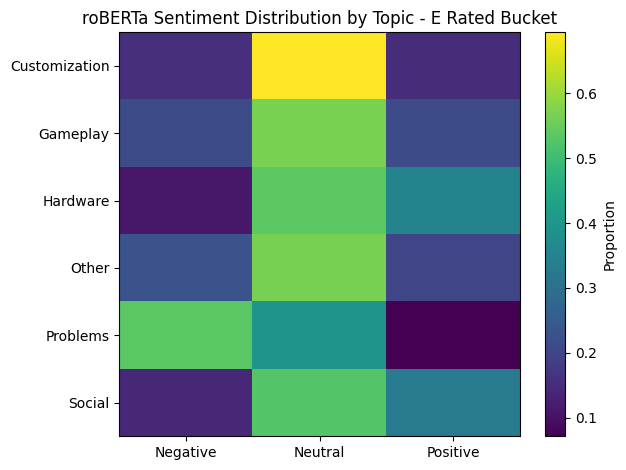

In [16]:
plt.imshow(bert_pct_E, aspect='auto')

plt.xticks(range(len(bert_pct_E.columns)), bert_pct_E.columns)
plt.yticks(range(len(bert_pct_E.index)), bert_pct_E.index)

plt.title("roBERTa Sentiment Distribution by Topic - E Rated Bucket")
plt.colorbar(label="Proportion")

plt.tight_layout()
plt.show()